In [1]:
from functools import reduce
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [2]:
LoRA_cfg = 2
GSOFT_cfg = 16

preds_path_ls = [
    ('Raw 1b',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\HumanEval\Raw_1b.bin'),
    # ('LoRA_1b-CR',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\HumanEval\LoRA_1b-cfg{LoRA_cfg}-CR.bin'),
    # ('GSOFT_1b-CR',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\HumanEval\GSOFT_1b-cfg{GSOFT_cfg}-CR.bin')
]

max_step = 16_000
for st in range(2_000, max_step+1, 2_000):
    preds_path_ls.append(
        (f'LoRA_1b-code st-{st}',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\HumanEval\LoRA_1b-cfg{LoRA_cfg}-st{st}.bin'),
    )

for st in range(2_000, max_step+1, 2_000):
    preds_path_ls.append(
        (f'GSOFT_1b-code st-{st}',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\HumanEval\GSOFT_1b-cfg{GSOFT_cfg}-st{st}.bin'),
    )

In [3]:
preds_dfs = {}

for run_name, preds_path in preds_path_ls:
    with open(preds_path, 'rb') as f:
        preds_dfs[run_name] = pickle.load(file=f)

        print(f"{run_name:16}: {preds_dfs[run_name].shape=}")

Raw 1b          : preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-2000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-4000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-6000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-8000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-10000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-12000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-14000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-16000: preds_dfs[run_name].shape=(164, 7)
GSOFT_1b-code st-2000: preds_dfs[run_name].shape=(164, 7)
GSOFT_1b-code st-4000: preds_dfs[run_name].shape=(164, 7)
GSOFT_1b-code st-6000: preds_dfs[run_name].shape=(164, 7)
GSOFT_1b-code st-8000: preds_dfs[run_name].shape=(164, 7)
GSOFT_1b-code st-10000: preds_dfs[run_name].shape=(164, 7)
GSOFT_1b-code st-12000: preds_dfs[run_name].shape=(164, 7)
GSOFT_1b-code st-14000: preds_dfs[run_name].shape=(164, 7)
GSOFT_1b-code st-16000: preds_dfs[run_name].shape=(164, 7)


In [4]:
run_name = 'GSOFT_1b-code st-2000'

In [5]:
preds_dfs[run_name]

,task_id,prompt,canonical_solution,test,entry_point,text_wa_answer,model_pred
0,HumanEval/0,from typing import List\n\n\ndef has_close_ele...,"for idx, elem in enumerate(numbers):\n ...","\n\nMETADATA = {\n 'author': 'jt',\n 'da...",has_close_elements,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'from typing import List im...
1,HumanEval/1,from typing import List\n\n\ndef separate_pare...,result = []\n current_string = []\n ...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",separate_paren_groups,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'from typing import List d...
2,HumanEval/2,\n\ndef truncate_number(number: float) -> floa...,return number % 1.0\n,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",truncate_number,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'def truncate_number(number...
3,HumanEval/3,from typing import List\n\n\ndef below_zero(op...,balance = 0\n\n for op in operations:\n...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",below_zero,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'from typing import List d...
4,HumanEval/4,from typing import List\n\n\ndef mean_absolute...,mean = sum(numbers) / len(numbers)\n re...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",mean_absolute_deviation,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'from typing import List d...
...,...,...,...,...,...,...,...
159,HumanEval/159,"\ndef eat(number, need, remaining):\n """"""\n...",if(need <= remaining):\n return [ n...,def check(candidate):\n\n # Check some simp...,eat,<|begin_of_text|><|start_header_id|>system<|en...,"{'generated_text': 'def eat(number, need, rema..."
160,HumanEval/160,"\ndef do_algebra(operator, operand):\n """"""\...",expression = str(operand[0])\n for oprt...,def check(candidate):\n\n # Check some simp...,do_algebra,<|begin_of_text|><|start_header_id|>system<|en...,"{'generated_text': 'def do_algebra(operator, o..."
161,HumanEval/161,"\ndef solve(s):\n """"""You are given a string...",flg = 0\n idx = 0\n new_str = list(s...,def check(candidate):\n\n # Check some simp...,solve,<|begin_of_text|><|start_header_id|>system<|en...,"{'generated_text': 'def solve(s): res = """"..."
162,HumanEval/162,"\ndef string_to_md5(text):\n """"""\n Given...",import hashlib\n return hashlib.md5(tex...,def check(candidate):\n\n # Check some simp...,string_to_md5,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'import hashlib def string...


In [6]:
import itertools
import re

def parse_compleetion(generated: str, entry_point: str) -> str:
    entry_pos = generated.find(entry_point)

    code_lines = generated[entry_pos:].split('\n')
    code_lines = itertools.takewhile(
        lambda line: re.match(r"^( {4}|\t)", line) or (len(line) == 0),
        itertools.islice(code_lines, 1, None)
    )

    return '\n'.join(code_lines)

In [7]:
idx = 1

# print(preds_dfs[run_name]['model_pred'][idx]['generated_text'])
# print(len(preds_dfs[run_name]['model_pred'][idx]['generated_text'].split('\n')[7]))

print(preds_dfs[run_name]['prompt'][idx])
print(parse_compleetion(preds_dfs[run_name]['model_pred'][idx]['generated_text'], entry_point=preds_dfs[run_name]['entry_point'][idx]))

from typing import List


def separate_paren_groups(paren_string: str) -> List[str]:
    """ Input to this function is a string containing multiple groups of nested parentheses. Your goal is to
    separate those group into separate strings and return the list of those.
    Separate groups are balanced (each open brace is properly closed) and not nested within each other
    Ignore any spaces in the input string.
    >>> separate_paren_groups('( ) (( )) (( )( ))')
    ['()', '(())', '(()())']
    """

    stack = []
    result = []
    for char in paren_string:
        if char == '(':
            stack.append(char)
        elif char == ')':
            if stack:
                stack.pop()
            else:
                result.append(char)
    return result


In [8]:
from typing import Dict, Any
import tempfile
import subprocess
import concurrent.futures
import sys
import os


def evaluate_single_solution(problem: Dict[str, Any], completion: str) -> bool:
    """
    Evaluate a single solution for a HumanEval problem.
    Returns True if all test cases pass, False otherwise.
    """
    # Combine prompt, completion and test code
    full_code = (
        problem["prompt"] + 
        completion + 
        "\n" +
        problem["test"] +
        "\n\n" +
        f"check({problem['entry_point']})"
    )

    # print(full_code)

    # Create temporary file to execute the code
    with tempfile.TemporaryDirectory() as temp_dir:
        script_path = os.path.join(temp_dir, "script.py")
        # Write the script to a temporary file
        with open(script_path, "w", encoding='utf-8') as f:
            f.write(full_code)
        
        result = {"stdout": None, "stderr": None, "success": False, "returncode": None, "error_type": None}
        try:
            # Run the code with a timeout
            process = subprocess.run(
                [sys.executable, script_path],
                # capture_output=True,
                text=True,
                timeout=5,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                cwd=temp_dir,
            )
            result["stdout"] = process.stdout
            result["stderr"] = process.stderr
            result["returncode"] = process.returncode
            result["success"] = process.returncode == 0
        except subprocess.TimeoutExpired:
            result["stderr"] = "Script execution timed out."
        except Exception as e:
            result["stderr"] = f"Error during script execution: {e}"
    
    if not result["success"]:
        error_type = re.findall('AssertionError|SyntaxError|NameError', result["stderr"])
        result["error_type"] = 'Smth else' if len(error_type) == 0 else error_type[0]

    return result['success'], result

In [9]:
def score_run(preds_df: pd.DataFrame) -> tuple[float, list[str], list]:
    score = 0
    error_types = []
    eval_results = []

    assert all(
        'def check(candidate):' in preds_df['test'][idx]
        for idx in range(preds_df.shape[0])
    )

    for idx in range(preds_df.shape[0]):
        success, result = evaluate_single_solution(
            problem=dict(preds_df.iloc[idx]),
            completion=parse_compleetion(preds_df['model_pred'][idx]['generated_text'], entry_point=preds_df['entry_point'][idx])
        )

        score += success
        error_types.append(result['error_type'])
        eval_results.append(result)
    
    score = score / preds_dfs[run_name].shape[0]

    return score, error_types, eval_results

In [10]:
scores = {}
err_types = {}
eval_results = {}

for run_name in preds_dfs.keys():
    score, error_type, eval_result = score_run(preds_dfs[run_name])
    scores[run_name] = score
    err_types[run_name] = error_type
    eval_results[run_name] = eval_result

    print(f"{run_name=:24}\t\t{score:.4f}")

run_name=Raw 1b                  		0.2805
run_name=LoRA_1b-code st-2000    		0.3354
run_name=LoRA_1b-code st-4000    		0.3354
run_name=LoRA_1b-code st-6000    		0.3720
run_name=LoRA_1b-code st-8000    		0.3963
run_name=LoRA_1b-code st-10000   		0.3780
run_name=LoRA_1b-code st-12000   		0.4085
run_name=LoRA_1b-code st-14000   		0.4024
run_name=LoRA_1b-code st-16000   		0.4329
run_name=GSOFT_1b-code st-2000   		0.2866
run_name=GSOFT_1b-code st-4000   		0.2805
run_name=GSOFT_1b-code st-6000   		0.2683
run_name=GSOFT_1b-code st-8000   		0.2744
run_name=GSOFT_1b-code st-10000  		0.2805
run_name=GSOFT_1b-code st-12000  		0.2805
run_name=GSOFT_1b-code st-14000  		0.2805
run_name=GSOFT_1b-code st-16000  		0.2866


In [11]:
LoRA_scores = [scores['LoRA_1b-CR']]
LoRA_scores += [
    scores[f'LoRA_1b-code st-{st}']
    for st in range(2000, max_step+1,2000)
]

GSOFT_scores = [scores['GSOFT_1b-CR']]
GSOFT_scores += [
    scores[f'GSOFT_1b-code st-{st}']
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=LoRA_scores,
    label='LoRA tuned'
)

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=GSOFT_scores,
    label='GSOFT tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[scores['Raw 1b'], scores['Raw 1b']],
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('Tuning')
plt.ylabel('HumanEval top-1 accuracy')
plt.legend()

KeyError: 'LoRA_1b-CR'

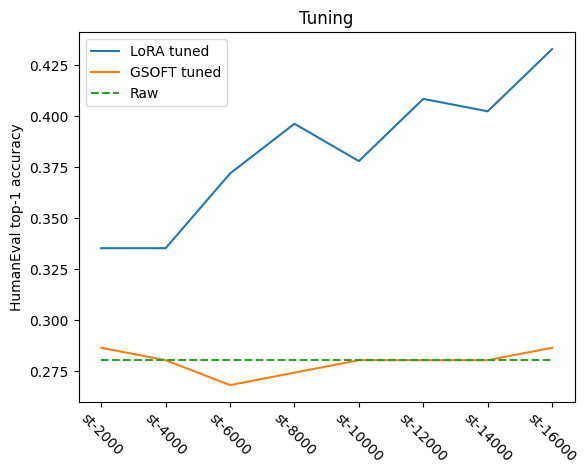

In [11]:
LoRA_scores = [
    scores[f'LoRA_1b-code st-{st}']
    for st in range(2000, max_step+1,2000)
]

GSOFT_scores = [
    scores[f'GSOFT_1b-code st-{st}']
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(2_000, max_step+1, 2000),
    y=LoRA_scores,
    label='LoRA tuned'
)

sns.lineplot(
    x=range(2_000, max_step+1, 2000),
    y=GSOFT_scores,
    label='GSOFT tuned'
)

sns.lineplot(
    x=[2_000, max_step],
    y=[scores['Raw 1b'], scores['Raw 1b']],
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(2_000, max_step+1,2000),
    labels=[f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('Tuning')
plt.ylabel('HumanEval top-1 accuracy')
plt.legend()

In [23]:
err_types.keys()

dict_keys(['Raw 1b', 'LoRA_1b-code st-2000', 'LoRA_1b-code st-4000', 'GSOFT_1b-code st-2000', 'GSOFT_1b-code st-4000'])

In [12]:
from collections import Counter

# print("LoRA-2000:", '\n\t'.join(map(lambda item: f"{item[0]}: {item[1]}", Counter(err_types['LoRA_1b-code st-2000']).most_common())), sep='\n\t', end='\n\n')
# print("LoRA-4000:", '\n\t'.join(map(lambda item: f"{item[0]}: {item[1]}", Counter(err_types['LoRA_1b-code st-4000']).most_common())), sep='\n\t', end='\n\n')

for st in range(2_000, max_step+1, 2_000):
    print(f"GSOFT-{st}:", '\n\t'.join(map(lambda item: f"{item[0]}: {item[1]}", Counter(err_types[f'GSOFT_1b-code st-{st}']).most_common())), sep='\n\t', end='\n\n')

GSOFT-2000:
	AssertionError: 104
	None: 47
	Smth else: 9
	NameError: 3
	SyntaxError: 1

GSOFT-4000:
	AssertionError: 96
	None: 46
	Smth else: 14
	SyntaxError: 4
	NameError: 4

GSOFT-6000:
	AssertionError: 91
	None: 44
	Smth else: 16
	SyntaxError: 8
	NameError: 5

GSOFT-8000:
	AssertionError: 92
	None: 45
	Smth else: 15
	SyntaxError: 7
	NameError: 5

GSOFT-10000:
	AssertionError: 92
	None: 46
	Smth else: 14
	SyntaxError: 8
	NameError: 4

GSOFT-12000:
	AssertionError: 94
	None: 46
	Smth else: 13
	SyntaxError: 7
	NameError: 4

GSOFT-14000:
	AssertionError: 94
	None: 46
	Smth else: 13
	SyntaxError: 7
	NameError: 4

GSOFT-16000:
	AssertionError: 92
	None: 47
	Smth else: 14
	SyntaxError: 6
	NameError: 5



In [26]:
run_name = 'GSOFT_1b-code st-10000'

for i, (err_type, result) in enumerate(zip(err_types[run_name], eval_results[run_name])):
    if err_type != 'Smth else':
        continue

    detailed_err_type = re.findall('\n\w+Error', result['stderr'])[0].strip()

    print(f"Problem {i:3}\tError={detailed_err_type}")

Problem   9	Error=IndexError
Problem  17	Error=KeyError
Problem  39	Error=IndexError
Problem  67	Error=ValueError
Problem  68	Error=ValueError
Problem  81	Error=KeyError
Problem  88	Error=RecursionError
Problem  99	Error=TypeError
Problem 105	Error=TypeError
Problem 130	Error=IndexError
Problem 136	Error=ValueError
Problem 145	Error=TypeError
Problem 148	Error=TypeError
Problem 160	Error=TypeError


In [27]:
run_name = 'GSOFT_1b-code st-10000'
target_err_type = 'NameError'

for i, (err_type, result) in enumerate(zip(err_types[run_name], eval_results[run_name])):
    if err_type != target_err_type:
        continue

    print(f"Problem {i:3}\tError={result['stderr']}")

Problem   4	Error=Traceback (most recent call last):
  File "C:\Users\Vladimir\AppData\Local\Temp\tmplxcvr7zg\script.py", line 38, in <module>
    check(mean_absolute_deviation)
  File "C:\Users\Vladimir\AppData\Local\Temp\tmplxcvr7zg\script.py", line 32, in check
    assert abs(candidate([1.0, 2.0, 3.0]) - 2.0/3.0) < 1e-6
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Vladimir\AppData\Local\Temp\tmplxcvr7zg\script.py", line 21, in mean_absolute_deviation
    mean = statistics.mean(numbers)
           ^^^^^^^^^^
NameError: name 'statistics' is not defined

Problem  32	Error=Traceback (most recent call last):
  File "C:\Users\Vladimir\AppData\Local\Temp\tmpn8f87izw\script.py", line 257, in <module>
    check(find_zero)
  File "C:\Users\Vladimir\AppData\Local\Temp\tmpn8f87izw\script.py", line 252, in check
    solution = candidate(copy.deepcopy(coeffs))
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Vladimir\AppData\Local\Temp\tmpn8f87izw\script.py", line 41

In [28]:
print(preds_dfs[run_name].iloc[32].model_pred['generated_text'])

import math


def poly(xs: list, x: float):
    """
    Evaluates polynomial with coefficients xs at point x.
    return xs[0] + xs[1] * x + xs[1] * x^2 +.... xs[n] * x^n
    """
    return sum([coeff * math.pow(x, i) for i, coeff in enumerate(xs)])


def find_zero(xs: list):
    """ xs are coefficients of a polynomial.
    find_zero find x such that poly(x) = 0.
    find_zero returns only only zero point, even if there are many.
    Moreover, find_zero only takes list xs having even number of coefficients
    and largest non zero coefficient as it guarantees
    a solution.
    >>> round(find_zero([1, 2]), 2) # f(x) = 1 + 2x
    -0.5
    >>> round(find_zero([-6, 11, -6, 1]), 2) # (x - 1) * (x - 2) * (x - 3) = -6 + 11x - 6x^2 + x^3
    1.0
    """
    # Check if all coefficients are non-zero
    if not all(coeff!= 0 for coeff in xs):
        raise ValueError("All coefficients must be non-zero")

    # Find the zero point
    for i in range(len(xs) - 1, -1, -1):
        if poly(xs, x) =

In [29]:
print(preds_dfs[run_name].iloc[32].prompt)

import math


def poly(xs: list, x: float):
    """
    Evaluates polynomial with coefficients xs at point x.
    return xs[0] + xs[1] * x + xs[1] * x^2 + .... xs[n] * x^n
    """
    return sum([coeff * math.pow(x, i) for i, coeff in enumerate(xs)])


def find_zero(xs: list):
    """ xs are coefficients of a polynomial.
    find_zero find x such that poly(x) = 0.
    find_zero returns only only zero point, even if there are many.
    Moreover, find_zero only takes list xs having even number of coefficients
    and largest non zero coefficient as it guarantees
    a solution.
    >>> round(find_zero([1, 2]), 2) # f(x) = 1 + 2x
    -0.5
    >>> round(find_zero([-6, 11, -6, 1]), 2) # (x - 1) * (x - 2) * (x - 3) = -6 + 11x - 6x^2 + x^3
    1.0
    """

